In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
# Your value-added results (6-digit, stream-specific)
venky_df = pd.read_csv("venky_va_501502_bpc.csv")

# Saee’s value-added results (5-digit college-level)
saee_df = pd.read_stata("saee_va_30016base.dta")

# Master mapping dataset
master_df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")


In [7]:
saee_df.head()

,coll_code,district,coll_name,parm,VA_5,stderr_5,dof_5,t_5,p_5,min95_5,...,VA_3,stderr_3,dof_3,t_3,p_3,min95_3,max95_3,clean_string,sixdigitcode,TSJC
0,30001.0,Adilabad,GOVT JUNIOR COLLEGE BOYS,30001.coll_code,-29.354523,3.134721,37892,-9.364317,8.061329e-21,-35.498659,...,-29.137205,3.134716,37874,-9.295006,1.547961e-20,-35.281332,-22.993078,30001,,0.0
1,30002.0,Adilabad,GOVT JR COLLEGE GIRLS,30002.coll_code,-16.169211,2.632412,37892,-6.142355,8.211408e-10,-21.328810,...,-15.806754,2.632402,37874,-6.004688,1.934425e-09,-20.966332,-10.647175,30002,,0.0
2,30003.0,Adilabad,GOVT JR COLLEGE,30003.coll_code,-8.752134,3.097757,37892,-2.825313,4.725908e-03,-14.823820,...,-8.774804,3.097925,37874,-2.832478,4.621317e-03,-14.846820,-2.702788,30003,,0.0
3,30004.0,Adilabad,GOVT JR COLLEGE,30004.coll_code,-8.473180,5.773027,37892,-1.467719,1.421889e-01,-19.788465,...,-7.947490,5.776790,37874,-1.375762,1.689034e-01,-19.270152,3.375173,30004,,0.0
4,30005.0,Adilabad,GOVT JR COLLEGE,30005.coll_code,-10.023411,4.580825,37892,-2.188124,2.866668e-02,-19.001949,...,-9.969292,4.580471,37874,-2.176477,2.952575e-02,-18.947137,-0.991446,30005,,0.0


In [8]:
mapping = (
    master_df[["allotted_JC_code", "coll_code_went"]]
    .dropna()
    .drop_duplicates()
)

# normalize formats
mapping["allotted_JC_code"] = mapping["allotted_JC_code"].astype(str).str.lower().str.strip()
mapping["coll_code_went"] = mapping["coll_code_went"].astype(str).str.strip()

print("Mapping rows:", mapping.shape[0])
mapping.head()


Mapping rows: 1846


,allotted_JC_code,coll_code_went
0,,54018.0
1,,56234.0
2,,56024.0
3,508402_bpc,50018.0
4,511901_mpc,42008.0


In [9]:
venky_df = venky_df.rename(columns={
    "college_code": "allotted_JC_code",
    "value_added": "venky_VA"
})

venky_df["allotted_JC_code"] = venky_df["allotted_JC_code"].astype(str).str.lower().str.strip()

venky_df = venky_df[["allotted_JC_code", "venky_VA", "std_error"]].dropna()

print("Your VA rows:", venky_df.shape[0])
venky_df.head()


Your VA rows: 192


,allotted_JC_code,venky_VA,std_error
0,501601_mpc,1.190646,0.590301
1,501602_bpc,0.840444,0.416157
2,501801_mpc,0.504418,0.421540
3,501802_bpc,0.894981,0.410170
4,501903_mec,-1.930657,0.684271


In [10]:
saee_df = saee_df.rename(columns={
    "coll_code": "coll_code_went",
    "VA_5": "saee_VA"
})

saee_df["coll_code_went"] = saee_df["coll_code_went"].astype(str).str.strip()

saee_df = saee_df[["coll_code_went", "saee_VA", "stderr_5"]].dropna()

print("Saee VA rows:", saee_df.shape[0])
saee_df.head()


Saee VA rows: 1722


,coll_code_went,saee_VA,stderr_5
0,30001.0,-29.354523,3.134721
1,30002.0,-16.169211,2.632412
2,30003.0,-8.752134,3.097757
3,30004.0,-8.473180,5.773027
4,30005.0,-10.023411,4.580825


In [11]:
# Step 1: your VA (6-digit) → mapping
merged = venky_df.merge(
    mapping,
    on="allotted_JC_code",
    how="left"
)

# Step 2: bring in Saee’s VA (5-digit)
merged = merged.merge(
    saee_df,
    on="coll_code_went",
    how="left"
)

print("Final merged rows:", merged.shape[0])
merged.head()


Final merged rows: 192


,allotted_JC_code,venky_VA,std_error,coll_code_went,saee_VA,stderr_5
0,501601_mpc,1.190646,0.590301,33014.0,-7.202116,2.071029
1,501602_bpc,0.840444,0.416157,33014.0,-7.202116,2.071029
2,501801_mpc,0.504418,0.421540,31016.0,-3.135446,2.201384
3,501802_bpc,0.894981,0.410170,31016.0,-3.135446,2.201384
4,501903_mec,-1.930657,0.684271,33013.0,-5.981785,2.259298


In [12]:
print("Streams with Saee match:",
      merged["saee_VA"].notna().sum())

print("Streams without Saee match:",
      merged["saee_VA"].isna().sum())


Streams with Saee match: 192
Streams without Saee match: 0


In [13]:
plot_df = merged.dropna(subset=["venky_VA", "saee_VA"])
print("Plotting rows:", plot_df.shape[0])


Plotting rows: 192


In [20]:
import numpy as np
import matplotlib.pyplot as plt

# X-axis (index or any ordering variable)
x = np.arange(len(merged))

# ---- Method 1: venky ----
y1 = merged['venky_VA']
se1 = merged['std_error']
low1 = y1 - 1.96 * se1
high1 = y1 + 1.96 * se1

# ---- Method 2: saee ----
y2 = merged['saee_VA']
se2 = merged['stderr_5']
low2 = y2 - 1.96 * se2
high2 = y2 + 1.96 * se2

# ---- Plot ----
plt.figure(figsize=(10, 6))

# venky_VA
plt.errorbar(
    x - 0.05,
    y1,
    yerr=[y1 - low1, high1 - y1],
    fmt='o',
    capsize=4,
    label='Regression 1 VA'
)

# saee_VA
plt.errorbar(
    x + 0.05,
    y2,
    yerr=[y2 - low2, high2 - y2],
    fmt='s',
    capsize=4,
    label='Reference VA'
)

# ---- CI overlap (thick line) ----
overlap_low = np.maximum(low1, low2)
overlap_high = np.minimum(high1, high2)

for xi, lo, hi in zip(x, overlap_low, overlap_high):
    if hi > lo:
        plt.vlines(xi, lo, hi, linewidth=4, alpha=0.4)

# ---- Formatting ----
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Observation')
plt.ylabel('VA Estimate')
plt.title('Regression 1 vs Reference Value-Added with 95% Confidence Intervals')
plt.legend()
plt.tight_layout()

plt.show()


NameError: name 'stream_v_direct' is not defined

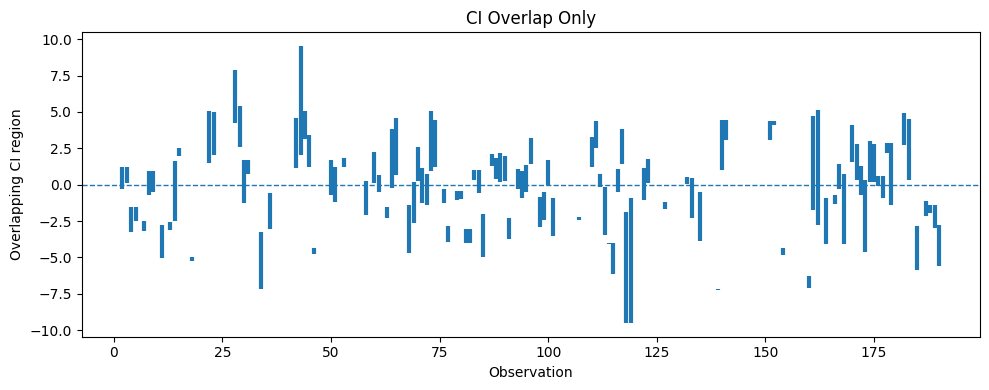

In [15]:
plt.figure(figsize=(10, 4))

for xi, lo, hi in zip(x, overlap_low, overlap_high):
    if hi > lo:
        plt.vlines(xi, lo, hi, linewidth=3)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('Observation')
plt.ylabel('Overlapping CI region')
plt.title('CI Overlap Only')
plt.tight_layout()
plt.show()


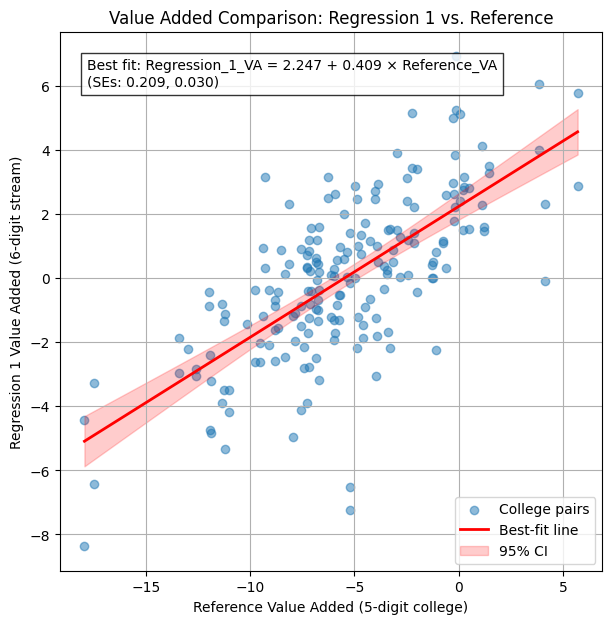

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# DATA
# -----------------------------
x = plot_df["saee_VA"].astype(float)
y = plot_df["venky_VA"].astype(float)

# Drop missing values
mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

# -----------------------------
# OLS REGRESSION
# y = a + b x
# -----------------------------
X = sm.add_constant(x)
ols_model = sm.OLS(y, X).fit()

a, b = ols_model.params
a_se, b_se = ols_model.bse

# -----------------------------
# PREDICTION GRID + CI
# -----------------------------
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = sm.add_constant(x_grid)

pred = ols_model.get_prediction(X_grid)
pred_mean = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7, 7))

# Scatter
plt.scatter(
    x,
    y,
    alpha=0.5,
    label="College pairs"
)

# Best-fit line
plt.plot(
    x_grid,
    pred_mean,
    color="red",
    linewidth=2,
    label="Best-fit line"
)

# Confidence interval
plt.fill_between(
    x_grid,
    ci_low,
    ci_high,
    color="red",
    alpha=0.2,
    label="95% CI"
)

# Labels
plt.xlabel("Reference Value Added (5-digit college)")
plt.ylabel("Regression 1 Value Added (6-digit stream)")
plt.title("Value Added Comparison: Regression 1 vs. Reference")

# Equation annotation
eqn_text = (
    f"Best fit: Regression_1_VA = {a:.3f} "
    f"+ {b:.3f} × Reference_VA\n"
    f"(SEs: {a_se:.3f}, {b_se:.3f})"
)

plt.text(
    0.05,
    0.95,
    eqn_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.grid(True)
plt.show()


In [19]:
corr = plot_df["saee_VA"].corr(plot_df["venky_VA"])
print("Correlation between value-added estimates:", round(corr, 3))


Correlation between value-added estimates: 0.702


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
pair_bin_long = pd.read_csv("pair_bin_long.csv")

students = pd.read_csv("final_rudimentary_grouping.csv")[
    ["candidate_id_68k", "englishmarks_12", "allotted_JC_code"]
]

va_df = pd.read_csv("venky_va_501502_bpc.csv")


In [ ]:
pair_bin_long["student_id"] = pair_bin_long["student_id"].astype(str)
students["candidate_id_68k"] = students["candidate_id_68k"].astype(str)

students["allotted_JC_code"] = (
    students["allotted_JC_code"]
    .astype(str).str.lower().str.strip()
)

va_df["college_code"] = (
    va_df["college_code"]
    .astype(str).str.lower().str.strip()
)


In [ ]:
df = pair_bin_long.merge(
    students,
    left_on="student_id",
    right_on="candidate_id_68k",
    how="left"
)

df = df.dropna(subset=["englishmarks_12", "allotted_JC_code"])


In [ ]:
def extract_colleges(pair_id):
    core = pair_id.replace(".1", "")
    A, B = core.split("x")
    return A.lower(), B.lower()

df[["college_A", "college_B"]] = df["pair_id"].apply(
    lambda x: pd.Series(extract_colleges(x))
)


In [ ]:
df = df[
    (df["allotted_JC_code"] == df["college_A"]) |
    (df["allotted_JC_code"] == df["college_B"])
]


In [ ]:
df["englishmarks_12"] = pd.to_numeric(df["englishmarks_12"], errors="coerce")
bin_means = (
    df
    .groupby(["pair_id", "bin_id", "allotted_JC_code"])["englishmarks_12"]
    .mean()
    .reset_index()
)


In [ ]:
# -----------------------------
# STEP 6: Δ MARKS PER PAIR–BIN
# -----------------------------

# 1. Pivot to wide format
bin_wide = (
    bin_means
    .pivot(
        index=["pair_id", "bin_id"],
        columns="allotted_JC_code",
        values="englishmarks_12"
    )
    .reset_index()
)

# 2. Extract college A and B from pair_id (AxB.1)
def extract_colleges(pair_id):
    A, rest = pair_id.split("x")
    B = rest.split(".")[0]
    return A, B

bin_wide[["college_A", "college_B"]] = (
    bin_wide["pair_id"]
    .apply(lambda x: pd.Series(extract_colleges(x)))
)

# 3. Keep only rows where both colleges are present
bin_wide = bin_wide.dropna(
    subset=["college_A", "college_B"]
)

# 4. Compute Δ marks = mean(A) − mean(B)
bin_wide["delta_marks"] = bin_wide.apply(
    lambda r: r[r["college_A"]] - r[r["college_B"]],
    axis=1
)

delta_marks_df = bin_wide[
    ["pair_id", "bin_id", "college_A", "college_B", "delta_marks"]
]

print("Δ-marks rows:", delta_marks_df.shape[0])
display(delta_marks_df.head())


In [ ]:
va = pd.read_csv("venky_va_501502_bpc.csv")

va["college_code"] = va["college_code"].astype(str)


In [ ]:
# Merge VA for college A
delta_marks_df = delta_marks_df.merge(
    va.rename(columns={"college_code": "college_A", "value_added": "va_A"}),
    on="college_A",
    how="left"
)

# Merge VA for college B
delta_marks_df = delta_marks_df.merge(
    va.rename(columns={"college_code": "college_B", "value_added": "va_B"}),
    on="college_B",
    how="left"
)

# Compute Δ VA
delta_marks_df["delta_va"] = (
    delta_marks_df["va_A"] - delta_marks_df["va_B"]
)

# Drop incomplete cases
plot_df = delta_marks_df.dropna(
    subset=["delta_marks", "delta_va"]
)

print("Final plotting rows:", plot_df.shape[0])
display(plot_df.head())


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    plot_df["delta_marks"],
    plot_df["delta_va"],
    alpha=0.4
)

plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Difference in Mean Marks (College A − College B)")
plt.ylabel("Difference in Value Added (College A − College B)")
plt.title("Δ Marks vs Δ Value Added across Pair–Bins")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
pair_level_marks = (
    delta_marks_df
    .groupby(["pair_id", "college_A", "college_B"])["delta_marks"]
    .mean()
    .reset_index()
    .rename(columns={"delta_marks": "avg_delta_marks"})
)

print("College-pair rows:", pair_level_marks.shape[0])
display(pair_level_marks.head())


In [ ]:
# merge VA for college A
pair_level = pair_level_marks.merge(
    va.rename(columns={
        "college_code": "college_A",
        "value_added": "va_A"
    }),
    on="college_A",
    how="left"
)

# merge VA for college B
pair_level = pair_level.merge(
    va_df.rename(columns={
        "college_code": "college_B",
        "value_added": "va_B"
    }),
    on="college_B",
    how="left"
)

# compute Δ VA
pair_level["delta_va"] = pair_level["va_A"] - pair_level["va_B"]

display(pair_level.head())


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    pair_level["avg_delta_marks"],
    pair_level["delta_va"],
    alpha=0.6
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Average pre-college marks difference (A − B)")
plt.ylabel("Value-added difference (A − B)")
plt.title("College-pair comparison: pre-marks vs value-added")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# DATA
# -----------------------------
x = pair_level["avg_delta_marks"].astype(float)
y = pair_level["delta_va"].astype(float)

# Drop missing
mask = x.notna() & y.notna()
x = x[mask]
y = y[mask]

# -----------------------------
# OLS REGRESSION
# y = a + b x
# -----------------------------
X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

a, b = model.params
a_se, b_se = model.bse

# -----------------------------
# PREDICTIONS + CI
# -----------------------------
x_grid = np.linspace(x.min(), x.max(), 200)
X_grid = sm.add_constant(x_grid)

pred = model.get_prediction(X_grid)
y_hat = pred.predicted_mean
ci_low, ci_high = pred.conf_int().T

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7, 6))

# Scatter
plt.scatter(
    x,
    y,
    alpha=0.6,
    label="College pairs"
)

# Zero reference lines
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

# Best-fit line
plt.plot(
    x_grid,
    y_hat,
    color="red",
    linewidth=2,
    label="Best-fit line"
)

# Confidence interval
plt.fill_between(
    x_grid,
    ci_low,
    ci_high,
    color="red",
    alpha=0.2,
    label="95% CI"
)

# Labels
plt.xlabel("Average pre-college marks difference (A − B)")
plt.ylabel("Value-added difference (A − B)")
plt.title("College-pair comparison: pre-marks vs value-added")

# Equation annotation
eqn = (
    f"ΔVA = {a:.3f} + {b:.3f} × ΔMarks\n"
    f"(SEs: {a_se:.3f}, {b_se:.3f})"
)

plt.text(
    0.05,
    0.95,
    eqn,
    transform=plt.gca().transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.legend()
plt.tight_layout()
plt.show()
